In [1]:
import os, sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

ROOT = r"C:\Users\ACER\Desktop\NeuroNest"
if ROOT not in sys.path:
    sys.path.append(ROOT)

from ml.brain_tumor.training.dataset import NPYSegDataset
from ml.brain_tumor.models.unet import UNet



In [2]:
# setting up all the paths and config values before we run anything
# CKPT_PATH is where the trained model weights are saved
# VAL_IMAGES and VAL_MASKS are the folders with our validation data
CKPT_PATH  = os.path.join(ROOT, "ml", "brain_tumor", "checkpoints", "best_unet_flair_binary.pth")
VAL_IMAGES = os.path.join(ROOT, "ml", "brain_tumor", "processed", "val", "images")
VAL_MASKS  = os.path.join(ROOT, "ml", "brain_tumor", "processed", "val", "masks")

# BATCH_SIZE is how many images to process at once
# THRESHOLD is the cutoff — anything above 0.5 probability is counted as tumor
BATCH_SIZE = 8
THRESHOLD  = 0.5
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("using device:", DEVICE)
print("checkpoint path:", CKPT_PATH)

using device: cuda
checkpoint path: C:\Users\ACER\Desktop\NeuroNest\ml\brain_tumor\checkpoints\best_unet_flair_binary.pth


In [3]:
# loading the validation dataset and wrapping it in a dataloader
# the dataloader handles batching automatically so we don't have to do it manually
val_ds     = NPYSegDataset(VAL_IMAGES, VAL_MASKS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("total val images:", len(val_ds))
print("total batches:", len(val_loader))

total val images: 4995
total batches: 625


In [4]:
# building the unet model and loading the weights we saved during training
# weights_only=True is just to avoid a pytorch warning about security
# model.eval() switches off dropout/batchnorm training behaviour
model = UNet(in_channels=1, out_channels=1).to(DEVICE)
state_dict = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(state_dict)
model.eval()
print("model loaded, looks good")

model loaded, looks good


In [5]:
# helper functions to compute each evaluation metric per batch
# eps is a tiny value added to avoid dividing by zero

eps = 1e-6

# dice: measures overlap between prediction and ground truth (higher is better)
def dice(p, t):    return ((2*(p*t).sum(dim=(1,2,3))+eps) / (p.sum(dim=(1,2,3))+t.sum(dim=(1,2,3))+eps)).mean().item()

# iou (intersection over union): similar to dice but a stricter overlap measure
def iou(p, t):     inter=(p*t).sum(dim=(1,2,3)); union=p.sum(dim=(1,2,3))+t.sum(dim=(1,2,3))-inter; return ((inter+eps)/(union+eps)).mean().item()

# pixel accuracy: percentage of pixels the model got right
def pix_acc(p, t): return ((p==t).float().sum(dim=(1,2,3)) / p[0].numel()).mean().item()

# precision: of all pixels predicted as tumor, how many actually were
def prec(p, t):    tp=(p*t).sum(dim=(1,2,3)); fp=(p*(1-t)).sum(dim=(1,2,3)); return ((tp+eps)/(tp+fp+eps)).mean().item()

# recall: of all actual tumor pixels, how many did the model find
def rec(p, t):     tp=(p*t).sum(dim=(1,2,3)); fn=((1-p)*t).sum(dim=(1,2,3)); return ((tp+eps)/(tp+fn+eps)).mean().item()

In [6]:
# running the model on the entire validation set and collecting metrics
# torch.inference_mode() disables gradient tracking since we're just evaluating, not training
dice_list, iou_list, acc_list, prec_list, rec_list = [], [], [], [], []
sample_imgs, sample_preds, sample_msks = [], [], []  # we'll use these for the visualisation below

with torch.inference_mode():
    for imgs, msks in tqdm(val_loader, desc="running evaluation"):
        imgs, msks = imgs.to(DEVICE), msks.to(DEVICE)

        # forward pass , sigmoid converts raw logits to probabilities (0 to 1)
        probs  = torch.sigmoid(model(imgs))
        # threshold the probabilities to get a binary mask (tumor or not)
        preds  = (probs > THRESHOLD).float()
        msks_b = (msks > 0.5).float()

        # compute and store metrics for this batch
        dice_list.append(dice(preds, msks_b))
        iou_list.append(iou(preds, msks_b))
        acc_list.append(pix_acc(preds, msks_b))
        prec_list.append(prec(preds, msks_b))
        rec_list.append(rec(preds, msks_b))

        # save the first 6 images so we can visualise them later
        if len(sample_imgs) < 6:
            for j in range(min(6 - len(sample_imgs), imgs.shape[0])):
                sample_imgs.append(imgs[j, 0].cpu().numpy())
                sample_preds.append(preds[j, 0].cpu().numpy())
                sample_msks.append(msks_b[j, 0].cpu().numpy())

# average the per-batch metrics across the whole validation set
metrics = {
    "Dice"          : np.mean(dice_list),
    "IoU"           : np.mean(iou_list),
    "Pixel Accuracy": np.mean(acc_list),
    "Precision"     : np.mean(prec_list),
    "Recall"        : np.mean(rec_list),
}

print("results:\n")
for k, v in metrics.items():
    print(f"  {k:<18}: {v:.4f}")

running evaluation:   0%|          | 0/625 [00:00<?, ?it/s]

results:

  Dice              : 0.7694
  IoU               : 0.6899
  Pixel Accuracy    : 0.9945
  Precision         : 0.8888
  Recall            : 0.7630


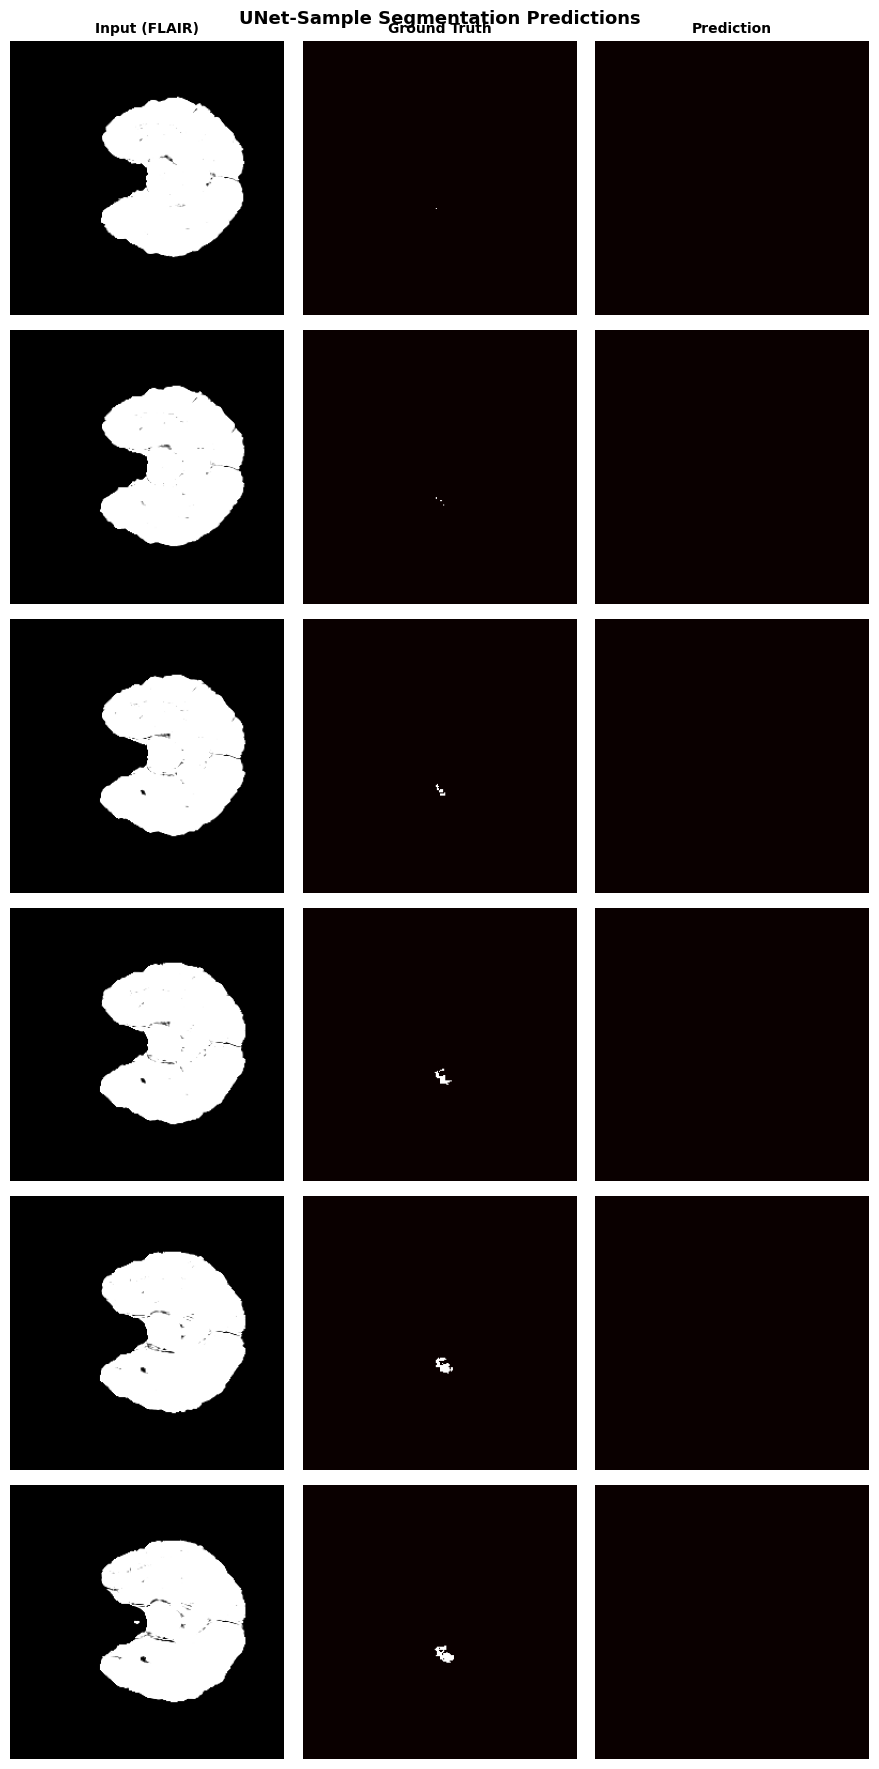

In [7]:
# showing 6 sample predictions side by side so we can visually check how well the model did
# each row is one image — left: original scan, middle: ground truth mask, right: model's prediction
n = len(sample_imgs)
fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
fig.suptitle("UNet-Sample Segmentation Predictions", fontsize=13, fontweight="bold")

col_titles = ["Input (FLAIR)", "Ground Truth", "Prediction"]
for idx in range(n):
    for c, (data, cmap) in enumerate([(sample_imgs[idx], "gray"),   # original MRI scan
                                       (sample_msks[idx], "hot"),    # actual tumor region
                                       (sample_preds[idx], "hot")]): # what the model predicted
        ax = axes[idx, c]
        ax.imshow(data, cmap=cmap, vmin=0, vmax=1)
        ax.axis("off")
        if idx == 0:
            ax.set_title(col_titles[c], fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()